# Ricostruzione Cross-Domain ed End-to-End

Questo notebook introduce due paradigmi fondamentali per la ricostruzione di immagini da misure indirette, con applicazione alla **Tomografia Computerizzata (CT)**.

---

## Contesto: il problema inverso nella CT

Nella tomografia computerizzata, l'immagine che vogliamo ottenere $x$ è misurata indirettamente attraverso un operatore di proiezione $K$ (la *trasformata di Radon*). Il risultato è un **sinogramma** $y$:

$$y = K(x) + \eta$$

dove $\eta$ è il rumore di misura. Il problema di ricostruire $x$ da $y$ è **mal posto** (ill-posed): piccole perturbazioni nel sinogramma possono causare grandi errori nella ricostruzione.

---

## 1 · Setup dell'ambiente

Questa cella prepara l'esperimento:

1. **Import** delle librerie necessarie (`torch`, `numpy`, `matplotlib`, ecc.) e del pacchetto locale `IPPy`.
2. **`MayoDataset`**: dataset PyTorch per immagini CT dal dataset Mayo Clinic (grayscale, 256×256).
3. **Device**: selezione automatica del dispositivo (`cuda`, `mps` o `cpu`).
4. **Operatore `K`**: `CTProjector` — simula l'acquisizione tomografica con geometria *parallel beam*, 60 angoli di proiezione e 512 pixel per rivelatore. Questo operatore usa internamente **ASTRA Toolbox** per calcolare la trasformata di Radon discreta.

> **Output atteso:** stampa del device, numero di immagini train/test e percorso dei pesi.


In [1]:
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

sys.path.append('..')
from IPPy import operators, utilities

book_root = Path('').resolve()
weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)


class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=256):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((data_shape, data_shape)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


device = utilities.get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

K = operators.CTProjector(
    img_shape=(256, 256),
    angles=np.linspace(0, np.pi, 60, endpoint=False),
    det_size=512,
    geometry='parallel',
)

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

/Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/IPPy/solvers.py:20: RuntimeWarning: numba is not installed. IPPy solvers will run without JIT acceleration.
  warnings.warn(


CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Device: mps
Training images: 3306
Test images: 327
Weights directory: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights


---
## 2 · Visualizzazione della pipeline CT: immagine → sinogramma → FBP

Questa cella mostra i tre passi fondamentali del processo tomografico:

1. **Immagine originale $x$**: il ground truth che vogliamo ricostruire.
2. **Sinogramma rumoroso $y^\delta$**: il risultato dell'acquisizione. Ogni riga del sinogramma corrisponde a una proiezione dell'immagine sotto un certo angolo. Si aggiunge rumore gaussiano con `noise_level=0.01` per simulare condizioni realistiche.
3. **Ricostruzione FBP $\tilde{x}$**: la *Filtered Back-Projection* è l'algoritmo analitico classico per ricostruire l'immagine dal sinogramma. Applica un filtro nel dominio delle frequenze (tipicamente *Ram-Lak*) e poi retro-proietta.

### Perché la FBP non basta?
La FBP assume:
- **Nessun rumore** nelle misure.
- **Numero sufficiente di angoli** (campionamento completo).

In pratica, con pochi angoli e rumore, la FBP produce artefatti a stella e banding. Questo motiva l'uso di reti neurali per migliorare la ricostruzione.

> **Output atteso:** tre immagini affiancate — ground truth, sinogramma rumoroso, e ricostruzione FBP.


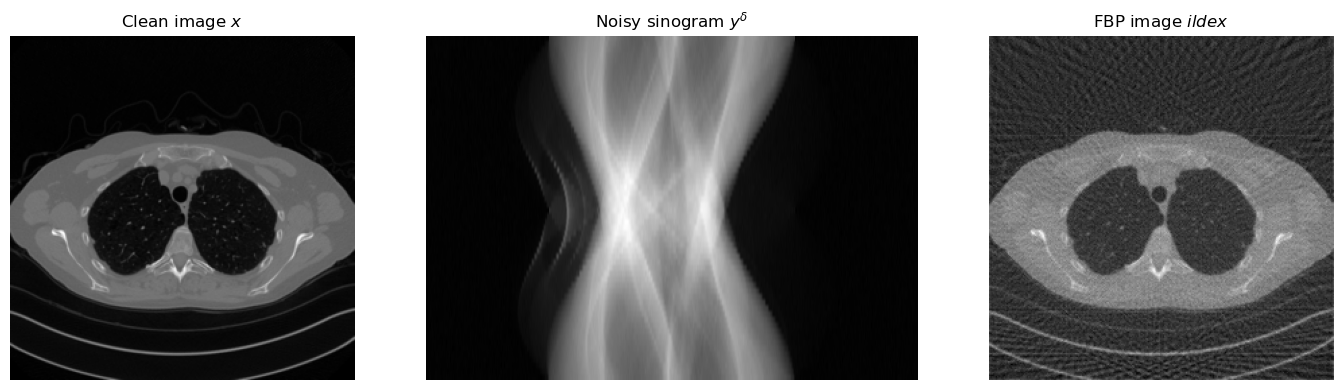

In [ ]:
torch.manual_seed(0)

x_example = test_dataset[0].unsqueeze(0).to(device)
with torch.no_grad():
    y_example = K(x_example)
    y_delta_example = y_example + utilities.gaussian_noise(y_example, noise_level=0.01)
    x_fbp_example = K.FBP(y_delta_example)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(x_example.cpu().squeeze(), cmap='gray')
plt.title('Clean image $x$')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(y_delta_example.cpu().squeeze(), cmap='gray', aspect='auto')
plt.title('Noisy sinogram $y^\delta$')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(x_fbp_example.cpu().squeeze(), cmap='gray')
plt.title('FBP image $\tilde{x}$')
plt.axis('off')

plt.tight_layout()
plt.show()

## 3 · Definizione dell'architettura UNet

Definiamo una **SimpleUNet** che sarà utilizzata come rete di post-processing nella pipeline **Cross-Domain**.

### Blocchi costruttivi

| Blocco | Struttura | Ruolo |
|---|---|---|
| **`DoubleConv`** | `Conv2d → ReLU → Conv2d → ReLU` | Estrazione di feature a risoluzione fissa |
| **`DownBlock`** | `MaxPool2d(2) → DoubleConv` | Encoder: riduce la risoluzione spaziale di 2× |
| **`UpBlock`** | `ConvTranspose2d(↑2) → cat(skip) → DoubleConv` | Decoder: raddoppia la risoluzione + skip connection |

### Architettura della `SimpleUNet`

```
Input (1, 256, 256)
  │
  ├─ enc1: DoubleConv(1, 32)          → s1 (32, 256, 256)  ──────────┐
  ├─ enc2: DownBlock(32, 64)          → s2 (64, 128, 128)  ─────┐    │
  ├─ enc3: DownBlock(64, 128)         → s3 (128, 64, 64)   ──┐  │    │
  ├─ bottleneck: DownBlock(128, 256)  → b  (256, 32, 32)     │  │    │
  ├─ dec3: UpBlock(256→128) + s3      → (128, 64, 64)   ─────┘  │    │
  ├─ dec2: UpBlock(128→64)  + s2      → (64, 128, 128)  ────────┘    │
  ├─ dec1: UpBlock(64→32)   + s1      → (32, 256, 256)  ─────────────┘
  └─ out_conv: Conv2d(32, 1, 1×1)     → Output (1, 256, 256)
```

> **Output atteso:** nessuno; la cella definisce le classi senza istanziarle.


In [3]:
import torch
from torch import nn


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.block(self.pool(x))


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = torch.nn.functional.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch)
        self.dec3 = UpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch)
        self.dec2 = UpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch)
        self.dec1 = UpBlock(2 * base_ch, base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


model = SimpleUNet(in_ch=1, out_ch=1, base_ch=32)
print(model)

SimpleUNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (enc2): DownBlock(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): DoubleConv(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
    )
  )
  (enc3): DownBlock(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): DoubleConv(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
     

---
## 4 · Training Cross-Domain: FBP + UNet

Questa cella implementa il paradigma **Cross-Domain** per la ricostruzione CT.

### Cos'è la ricostruzione Cross-Domain?

Il termine *Cross-Domain* indica che la pipeline attraversa **due domini** diversi:

1. **Dominio dei dati (sinogramma)**: il sinogramma $y^\delta$ vive nello spazio delle proiezioni (Radon). In questo dominio si applica la FBP, che è un operatore **analitico** (non appreso).
2. **Dominio dell'immagine**: la FBP produce una ricostruzione approssimata $\tilde{x}$ nel dominio delle immagini. Una rete neurale (UNet) raffina questa ricostruzione.

$$\hat{x} = f_\theta(\text{FBP}(y^\delta))$$

dove $f_\theta$ è la UNet con parametri $\theta$.

### Pipeline di training

```
x (ground truth)
    │
    ▼  K (forward model — non appreso)
y = K(x)
    │
    ▼  + rumore gaussiano
y^δ (sinogramma rumoroso)           ← DOMINIO SINOGRAMMA
    │
    ▼  FBP (operatore analitico — non appreso)
x̃ = FBP(y^δ)                        ← PASSAGGIO CROSS-DOMAIN
    │
    ▼  UNet f_θ (appresa)
x̂ = f_θ(x̃)                          ← DOMINIO IMMAGINE
    │
    ▼  Loss = MSE(x̂, x)
  Backprop su θ
```

### Dettagli implementativi
- **Ottimizzatore**: Adam con `lr=1e-3`.
- **Loss**: MSE tra la ricostruzione $\hat{x}$ e il ground truth $x$.
- **Epoche**: 5 (dimostrativo).
- I passi di **proiezione**, **rumore** e **FBP** sono eseguiti con `torch.no_grad()` — non si calcolano gradienti per l'operatore fisico.
- I pesi vengono salvati come `CTUNet.pth`.

### Vantaggi del Cross-Domain
- La FBP fornisce una ricostruzione iniziale ragionevole → la UNet deve solo "ripulire" gli artefatti.
- La rete lavora nello spazio delle immagini (256×256), più interpretabile.
- Non richiede di apprendere la fisica dell'operatore diretto.

### Limitazioni
- La FBP è un collo di bottiglia: se produce una ricostruzione molto degradata (es. pochi angoli), la UNet potrebbe non riuscire a recuperare i dettagli persi.
- L'informazione nel sinogramma viene "compressa" dalla FBP prima che la rete la veda.

> **Output atteso:** barra di progresso per ogni epoca + salvataggio dei pesi.


In [4]:
torch.manual_seed(0)

model = SimpleUNet(in_ch=1, out_ch=1, base_ch=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 5
noise_level = 0.01
history = []
weights_path = weights_dir / 'CTUNet.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + utilities.gaussian_noise(y_batch, noise_level=noise_level)
            x_fbp = K.FBP(y_batch)

        x_pred = model(x_fbp)
        loss = loss_fn(x_pred, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))


torch.save(model.state_dict(), weights_path)
print(f'Saved cross-domain UNet weights to: {weights_path}')

reloaded_model = SimpleUNet(in_ch=1, out_ch=1, base_ch=32)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

Epoch 1/5:   0%|          | 0/827 [00:00<?, ?it/s]

Epoch 2/5:   0%|          | 0/827 [00:00<?, ?it/s]

Epoch 3/5:   0%|          | 0/827 [00:00<?, ?it/s]

Epoch 4/5:   0%|          | 0/827 [00:00<?, ?it/s]

Epoch 5/5:   0%|          | 0/827 [00:00<?, ?it/s]

Saved cross-domain UNet weights to: /Users/mattia.dispigno/University/UniBo/computational imaging/Computational Imaging/weights/CTUNet.pth


SimpleUNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU()
    )
  )
  (enc2): DownBlock(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): DoubleConv(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
      )
    )
  )
  (enc3): DownBlock(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (block): DoubleConv(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
     

---
## 5 · Valutazione e confronto visivo

In questa cella valutiamo il modello addestrato su un'immagine di test:

1. Si genera il sinogramma rumoroso $y^\delta = K(x) + \eta$.
2. Si applica la FBP: $\tilde{x} = \text{FBP}(y^\delta)$.
3. Si raffina con la UNet: $\hat{x} = f_\theta(\tilde{x})$.
4. Si calcola la **MSE** sia della FBP ($\text{MSE}_{\text{FBP}}$) che della UNet ($\text{MSE}_{\text{UNet}}$) rispetto al ground truth.

### Cosa osservare nella figura
- La **FBP** produce artefatti a stella e banding, tipici della retro-proiezione con pochi angoli e rumore.
- La **UNet** rimuove efficacemente questi artefatti, producendo un'immagine più liscia e fedele.
- Il valore di **MSE** della UNet dovrebbe essere significativamente inferiore a quello della FBP.

Viene mostrato anche il **grafico della training loss** per verificare la convergenza del training.

> **Output atteso:** 4 immagini affiancate (ground truth, sinogramma, FBP, UNet) + grafico della loss.


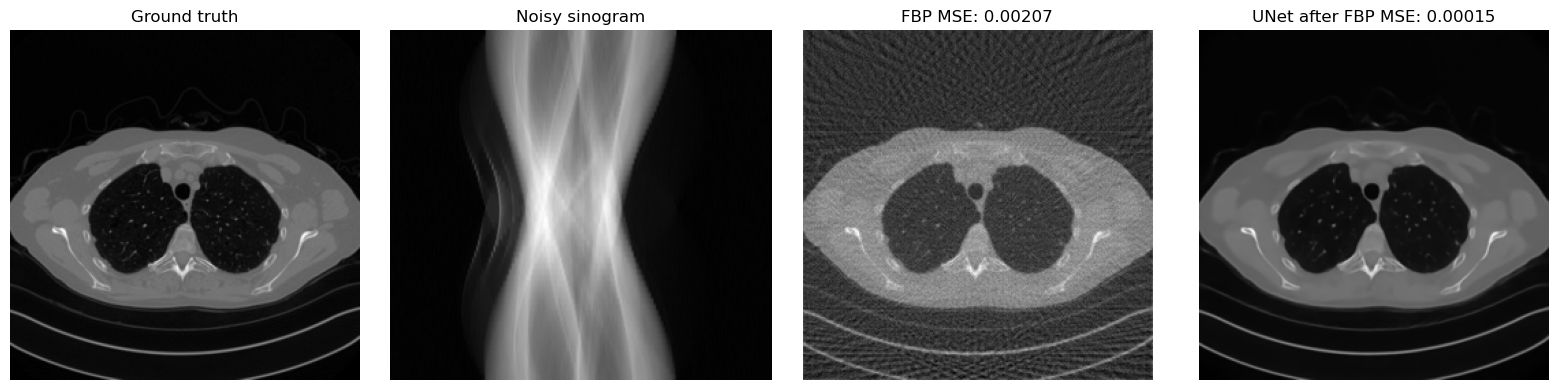

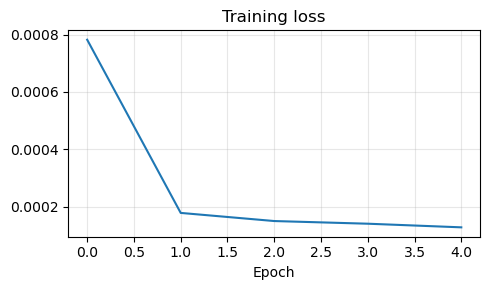

In [5]:
with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=noise_level)
    x_fbp = K.FBP(y_delta)
    x_rec = reloaded_model(x_fbp)

mse_fbp = torch.mean((x_fbp - x_true) ** 2).item()
mse_unet = torch.mean((x_rec - x_true) ** 2).item()

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray', aspect='auto')
plt.title('Noisy sinogram')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_fbp.cpu().squeeze(), cmap='gray')
plt.title(f'FBP MSE: {mse_fbp:.5f}')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title(f'UNet after FBP MSE: {mse_unet:.5f}')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6 · Esperimento: effetto del numero di angoli sulla ricostruzione FBP

Questa cella esplora un aspetto cruciale della ricostruzione tomografica: **quanto influisce il numero di angoli di proiezione sulla qualità della FBP?**

### Setup dell'esperimento
Si testa la stessa immagine con tre diversi numeri di angoli:

| Angoli | Copertura | Qualità attesa della FBP |
|---|---|---|
| **30** | Molto sparsa | Artefatti gravi, banding evidente |
| **60** | Moderata (usata nel training) | Artefatti moderati |
| **120** | Densa | Buona qualità, pochi artefatti |

### Cosa osservare
- Con **30 angoli**: il sinogramma ha poche righe e la FBP mostra forti artefatti a stella (streak artifacts). L'informazione è insufficiente per una ricostruzione fedele.
- Con **60 angoli**: qualità intermedia — gli artefatti sono visibili ma l'anatomia è riconoscibile.
- Con **120 angoli**: la FBP produce un risultato molto migliore, quasi privo di artefatti.

### Implicazione per il Cross-Domain
Questo esperimento evidenzia il **limite del paradigma Cross-Domain**: se il numero di angoli è troppo basso, la FBP perde informazione che nessuna rete potrà recuperare.
Un approccio **End-to-End** (che apprende direttamente dal sinogramma all'immagine, integrando la fisica nell'architettura) potrebbe gestire meglio questi casi, perché la rete ha accesso diretto ai dati grezzi prima della FBP.

> **Output atteso:** griglia di 3×2 con sinogramma e FBP per ciascun numero di angoli.


CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


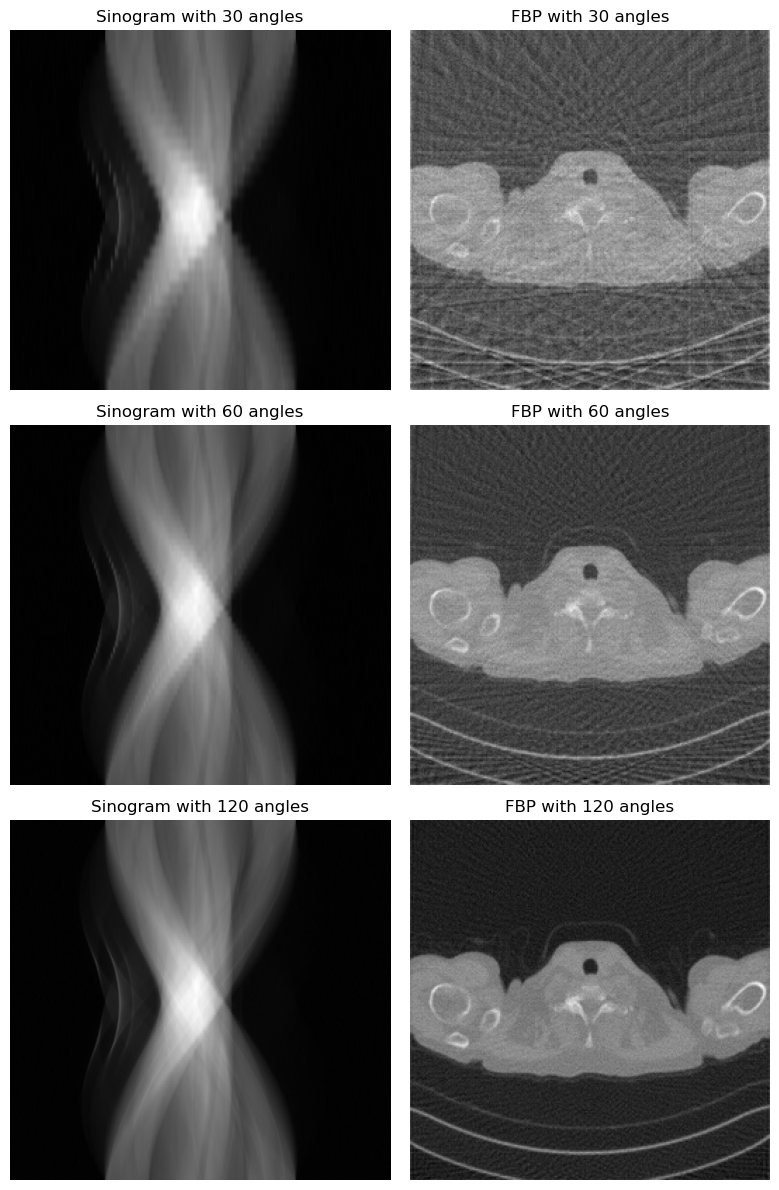

In [6]:
angles_list = [30, 60, 120]

x_true = test_dataset[1].unsqueeze(0).to(device)
fig, axes = plt.subplots(len(angles_list), 2, figsize=(8, 4 * len(angles_list)))

for row, n_angles in enumerate(angles_list):
    K_test = operators.CTProjector(
        img_shape=(256, 256),
        angles=np.linspace(0, np.pi, n_angles, endpoint=False),
        det_size=512,
        geometry='parallel',
    )

    with torch.no_grad():
        y_delta = K_test(x_true)
        y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)
        x_fbp = K_test.FBP(y_delta)

    axes[row, 0].imshow(y_delta.cpu().squeeze(), cmap='gray', aspect='auto')
    axes[row, 0].set_title(f'Sinogram with {n_angles} angles')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(x_fbp.cpu().squeeze(), cmap='gray')
    axes[row, 1].set_title(f'FBP with {n_angles} angles')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()